<a href="https://colab.research.google.com/github/Rony-pat/Clases/blob/main/Tarea_18_Aprendizaje_no_supervisado_%E2%80%93_Agrupamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

clientes = pd.read_csv('datos_clientes.csv')

clientes.drop_duplicates(inplace=True)
clientes['Edad'].fillna(clientes['Edad'].median(), inplace=True)
clientes['Ingresos'].fillna(clientes['Ingresos'].median(), inplace=True)
clientes['Gasto'].fillna(clientes['Gasto'].median(), inplace=True)
clientes['Puntuacion'].fillna(clientes['Puntuacion'].median(), inplace=True)


<ipython-input-2-6e59f5aea75d>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes['Edad'].fillna(clientes['Edad'].median(), inplace=True)
<ipython-input-2-6e59f5aea75d>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [3]:

clientes['Edad'] = clientes['Edad'].clip(18, 65)
clientes['Ingresos'] = clientes['Ingresos'].clip(1000, 50000)
clientes['Gasto'] = clientes['Gasto'].clip(10, 500)
clientes['Puntuacion'] = clientes['Puntuacion'].clip(1, 100)


In [4]:

X = clientes[['Edad', 'Ingresos', 'Gasto', 'Puntuacion']]


In [5]:

hca = AgglomerativeClustering(n_clusters=3)
clientes['Cluster_HCA'] = hca.fit_predict(X)


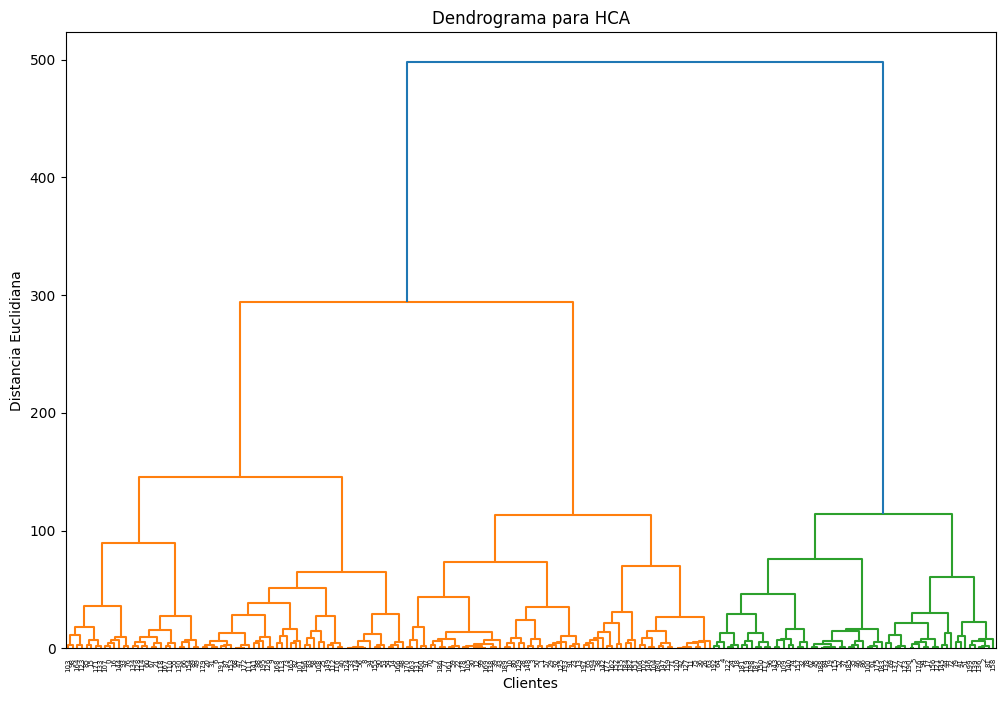

In [6]:

linked = linkage(X, 'ward')
plt.figure(figsize=(12, 8))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrograma para HCA')
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.show()

In [7]:

kmeans = KMeans(n_clusters=5, random_state=42)
clientes['Cluster_KMeans'] = kmeans.fit_predict(X)

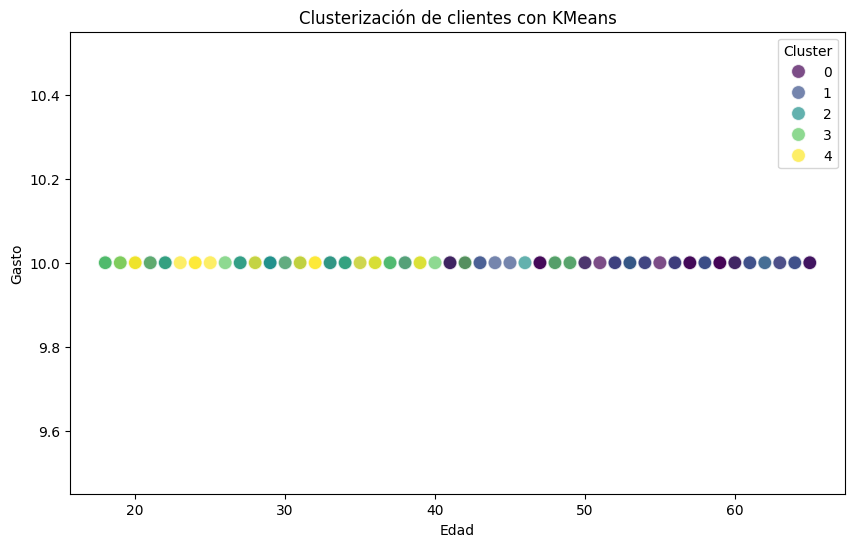

In [8]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=clientes, x='Edad', y='Gasto', hue='Cluster_KMeans', palette='viridis', s=100, alpha=0.7)
plt.title('Clusterización de clientes con KMeans')
plt.xlabel('Edad')
plt.ylabel('Gasto')
plt.legend(title='Cluster')
plt.show()

In [9]:

silhouette_scores = {}
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores[n_clusters] = silhouette_avg

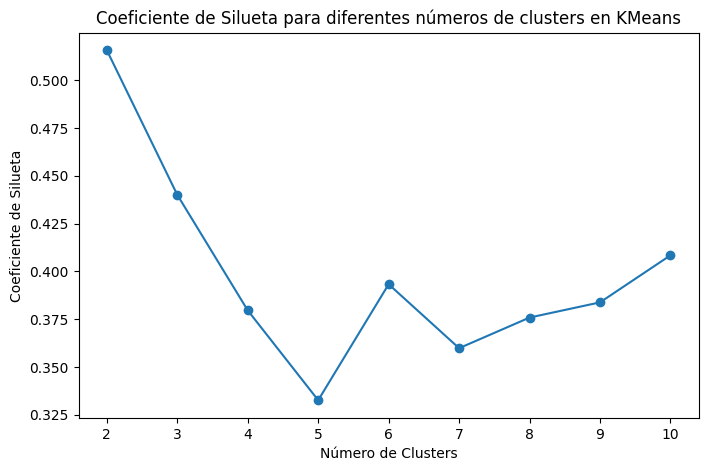

In [10]:

plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title('Coeficiente de Silueta para diferentes números de clusters en KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silueta')
plt.show()

In [11]:

opt_kmeans = max(silhouette_scores, key=silhouette_scores.get)
kmeans_opt = KMeans(n_clusters=opt_kmeans, random_state=42)
clientes['Cluster_KMeans_Opt'] = kmeans_opt.fit_predict(X)

In [13]:
columnas_numericas = ['Edad', 'Ingresos', 'Gasto', 'Puntuacion', 'Cluster_KMeans_Opt']
resultado_clusters = clientes[columnas_numericas].groupby('Cluster_KMeans_Opt').mean()

print("Número óptimo de clusters para KMeans:", opt_kmeans)
print("Análisis de los clusters obtenidos:")
print(resultado_clusters)

Número óptimo de clusters para KMeans: 2
Análisis de los clusters obtenidos:
                         Edad  Ingresos  Gasto  Puntuacion
Cluster_KMeans_Opt                                        
0                   44.813953    1000.0   10.0   81.406977
1                   40.061404    1000.0   10.0   28.280702
